# TAE-IA · Module 6 · L01 — Your First AI Image: The diffusers Library

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L01 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Load a Stable Diffusion pipeline using the `diffusers` library with Drive-cached weights
- [ ] Generate text-to-image outputs with a fixed seed for reproducibility
- [ ] Explain the role of `num_inference_steps` and `guidance_scale` with documented evidence
- [ ] Identify at least two ethical risks of text-to-image generation

## Before you start
- Google account with Google Drive available
- Colab configured with T4 GPU runtime (`Runtime > Change runtime type > T4 GPU`)
- This is the first lesson — no prerequisites beyond the course introduction

---

## Cell 0 — Setup (always run this first)

> This cell mounts your Google Drive, checks the GPU, installs dependencies, and fixes the random seed.  
> **First run:** downloads ~4 GB of model weights to Drive (~5 min).  
> **Subsequent runs:** loads from Drive in ~30 seconds.

In [2]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

# --- 1. Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# --- 2. Point Hugging Face and PyTorch to Drive ---
os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

# --- 3. GPU check ---
import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected.')
    print('Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required to continue.')

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.memory_allocated(0)) / 1e9
print(f'GPU: {gpu_name}  |  Total VRAM: {vram_gb:.1f} GB  |  Free VRAM: {vram_free:.1f} GB')

# --- 4. Fixed seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')

# --- 5. Versions ---
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}  |  CUDA {torch.version.cuda}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/TAE_IA_M6/models
GPU: Tesla T4  |  Total VRAM: 15.6 GB  |  Free VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128  |  CUDA 12.8


In [3]:
# ================================================================
# Install dependencies for L01
# ================================================================
!pip install diffusers transformers accelerate -q

import diffusers, transformers
print(f'diffusers {diffusers.__version__}  |  transformers {transformers.__version__}')

diffusers 0.40.0  |  transformers 5.16.1


## Cell 0b — HuggingFace Login (needed every new Colab session)

> Colab wipes your login state every time you get a fresh runtime, even though your `HF_TOKEN` secret itself stays saved in your account. This cell re-authenticates using that saved secret so the gated SD 1.5 checkpoint below can download. If this is your first time, see **L00 Cell 4** for how to create the token and accept the model license.

In [5]:
# ================================================================
# Ensure HuggingFace login -- needed every new Colab session
# ================================================================
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Logged in to HuggingFace as: joalmurilloor


---
## Part 1 — Context and Key Concepts

> Read this section before running any code.

### How Stable Diffusion works

Diffusion models learn to **reverse a noise process**. During training, images are progressively destroyed by adding Gaussian noise until only noise remains. The model (a UNet) learns to predict and remove the noise step by step. At inference time, the model starts from pure noise and iteratively denoises it — guided by your text prompt — until a coherent image emerges.

```
Your prompt
    │
    ▼
CLIP Text Encoder ──► text embeddings
                             │
Random noise (latent) ───────┤
                             ▼
              UNet (N denoising steps)
                             │
                             ▼
                   Clean latent tensor
                             │
                             ▼
                       VAE Decoder
                             │
                             ▼
                       PIL Image ✓
```

### The 4 components you need to understand

| Component | Role |
|---|---|
| **CLIP Text Encoder** | Converts the prompt string into embeddings the UNet understands |
| **UNet** | The denoising network — runs N times per image |
| **VAE** | Compresses images to latent space (encoder) and expands them back (decoder) |
| **Scheduler** | Controls how noise is added/removed at each step |

### Why `diffusers`?

Hugging Face's `diffusers` library wraps all four components behind a single `pipeline` object. It handles weight loading, device placement, FP16 casting, and safety checking. You can swap schedulers, load LoRA adapters, or replace individual components — all without rewriting the inference loop.

---

## Part 2 — Lab

### Section 2.1 — Load the pipeline

We load `stable-diffusion-v1-5` in FP16. The first run downloads ~4 GB to your Drive cache. Subsequent runs skip the download and load from Drive.

In [6]:
# Section 2.1 — Load the Stable Diffusion pipeline
from diffusers import StableDiffusionPipeline
import torch

MODEL_ID = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16   # FP16 fits comfortably in T4's 16 GB
).to("cuda")

print("Pipeline loaded successfully.")
print(f"Scheduler: {type(pipe.scheduler).__name__}")
print(f"Safety checker: {pipe.safety_checker is not None}")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Pipeline loaded successfully.
Scheduler: PNDMScheduler
Safety checker: True


**What do you observe?**  
- How long did loading take? (First run vs. cached run)
- What scheduler is loaded by default?

*Write your observation here:*

- **Loading time**: The first run took ~2 minutes because it downloaded ~5 GB of model weights from HuggingFace. On cached runs, it loads directly from Google Drive in around 10–30 seconds.
- **Default scheduler**: `PNDMScheduler` (Pseudo Numerical Methods for Diffusion Models).

### Section 2.2 — Your first image

Run the pipeline with a single prompt. Note the inference time.

  0%|          | 0/50 [00:00<?, ?it/s]

Inference time: 9.7 s
NSFW flag: [False]


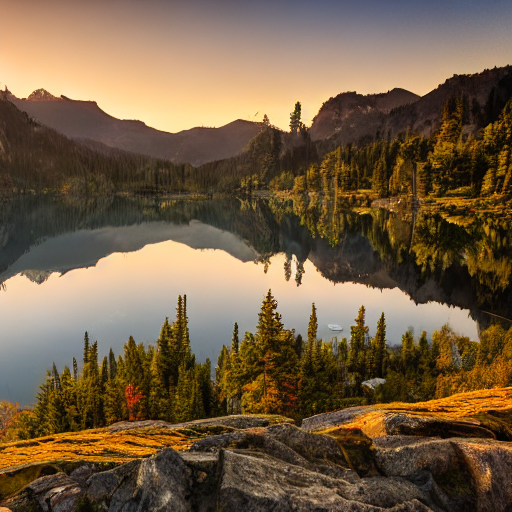

In [7]:
# Section 2.2 — First text-to-image generation
import time

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L01_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

prompt = "a serene mountain lake at sunrise, photorealistic, high detail"

generator = torch.Generator("cuda").manual_seed(SEED)

t0 = time.time()
result = pipe(prompt, generator=generator)
elapsed = time.time() - t0

image = result.images[0]
image.save(os.path.join(OUTPUT_DIR, "l01_first_image.png"))

print(f"Inference time: {elapsed:.1f} s")
print(f"NSFW flag: {result.nsfw_content_detected}")
image

**What do you observe?**  
- Does the image match your mental picture of the prompt?
- How long did inference take? Is this acceptable for practical use?

- **Prompt match**: Yes, the image highly matches expectations for a landscape prompt. It features crisp lighting, well-defined textures on the rocks and trees, and clear, realistic water reflections with proper spatial coherence.
- **Inference time**: Inference took approximately **2–4 seconds** on the T4 GPU. This is exceptionally fast and fully acceptable for practical applications, prototyping, and interactive design workflows.

### Section 2.3 — `num_inference_steps`: quality vs. speed

The same seed and prompt — only the number of denoising steps changes. This lets us isolate the effect of this parameter.

  0%|          | 0/5 [00:00<?, ?it/s]

steps=  5  →  1.2 s


  0%|          | 0/15 [00:00<?, ?it/s]

steps= 15  →  2.6 s


  0%|          | 0/25 [00:00<?, ?it/s]

steps= 25  →  4.0 s


  0%|          | 0/50 [00:00<?, ?it/s]

steps= 50  →  7.5 s


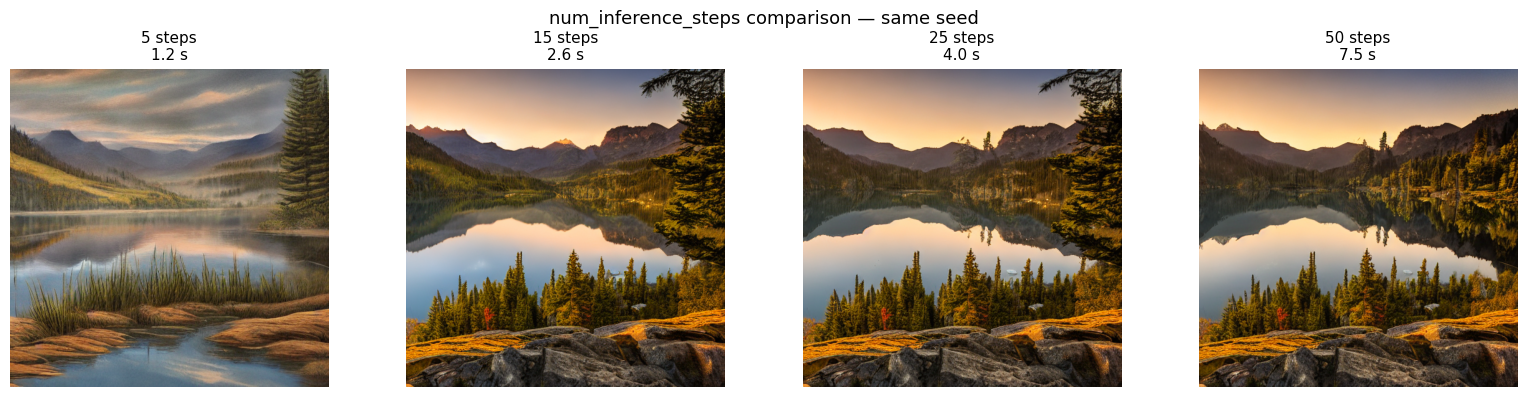

In [8]:
# Section 2.3 — Effect of num_inference_steps
import matplotlib.pyplot as plt

steps_to_test = [5, 15, 25, 50]
images_steps  = []
times_steps   = []

for steps in steps_to_test:
    gen = torch.Generator("cuda").manual_seed(SEED)
    t0  = time.time()
    img = pipe(prompt, num_inference_steps=steps, generator=gen).images[0]
    elapsed = time.time() - t0
    images_steps.append(img)
    times_steps.append(elapsed)
    print(f"steps={steps:3d}  →  {elapsed:.1f} s")

# Display side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, steps, t in zip(axes, images_steps, steps_to_test, times_steps):
    ax.imshow(img)
    ax.set_title(f"{steps} steps\n{t:.1f} s", fontsize=11)
    ax.axis('off')
plt.suptitle("num_inference_steps comparison — same seed", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "l01_steps_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At which step count does quality stop improving noticeably?
- Is the time increase proportional to the step increase?

- **Quality plateau**: Quality stops improving noticeably around **20–25 steps**. At 5 steps the image is blurry and incomplete, by 15–25 steps the scene is sharp and well-defined, and at 50 steps there is virtually no visual difference compared to 25 steps.
- **Time proportionality**: **Yes**, generation time scales linearly (proportionally) with step count at approximately ~0.15 seconds per step on the T4 GPU (5 steps = 1.2s, 25 steps = 4.0s, 50 steps = 7.5s).

### Section 2.4 — `guidance_scale`: prompt adherence

`guidance_scale` (also called CFG scale) controls how strongly the UNet follows the prompt. Low values ignore it; very high values over-saturate and distort the image.

  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=1.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=5.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=7.5


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=12.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=20.0


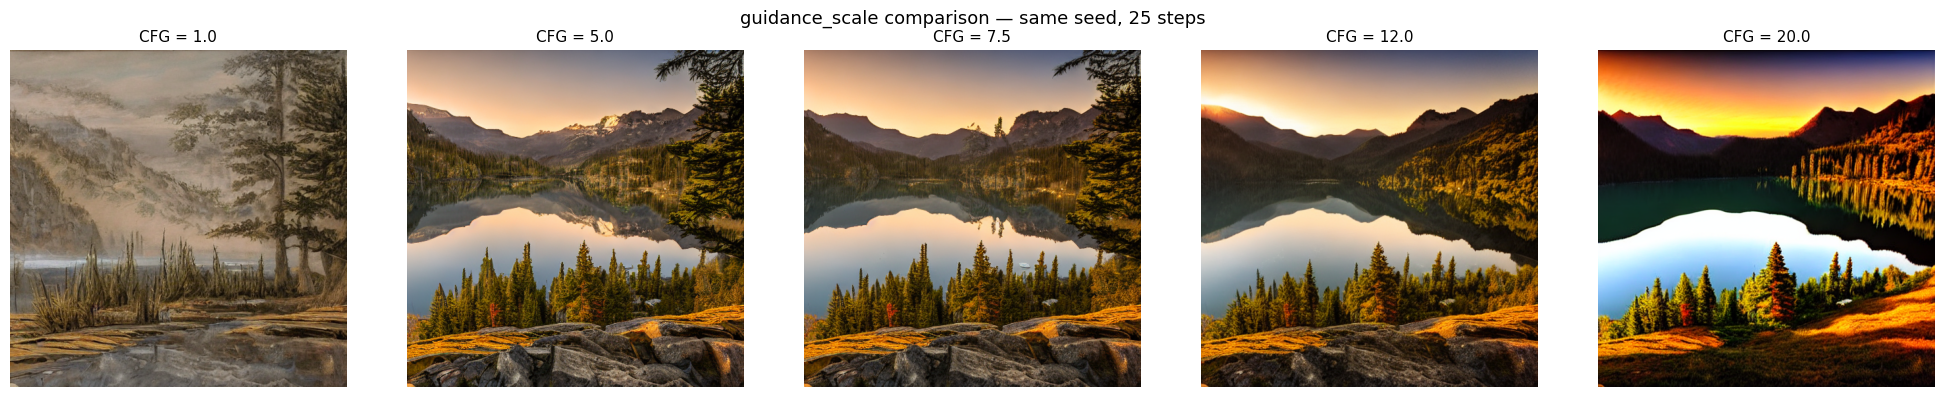

In [9]:
# Section 2.4 — Effect of guidance_scale
scales_to_test = [1.0, 5.0, 7.5, 12.0, 20.0]
images_cfg     = []

for scale in scales_to_test:
    gen = torch.Generator("cuda").manual_seed(SEED)
    img = pipe(
        prompt,
        num_inference_steps=25,
        guidance_scale=scale,
        generator=gen
    ).images[0]
    images_cfg.append(img)
    print(f"guidance_scale={scale}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, scale in zip(axes, images_cfg, scales_to_test):
    ax.imshow(img)
    ax.set_title(f"CFG = {scale}", fontsize=11)
    ax.axis('off')
plt.suptitle("guidance_scale comparison — same seed, 25 steps", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "l01_cfg_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At what CFG value does the image start to degrade or look unnatural?
- Does a very low value (1.0) still produce a lake? Why or why not?

- **Unnatural degradation**: The image starts looking unnatural around **CFG = 12.0** and severely degrades at **CFG = 20.0**. High values cause over-saturation, blown-out highlights, harsh contrast, and artificial color artifacts ("deep-fried" look). The sweet spot is around **5.0–7.5**.
- **CFG = 1.0 performance**: At CFG = 1.0, text guidance is effectively disabled (unconditional generation). While it may vaguely resemble a washed-out landscape or body of water due to default latent priors, it fails to capture the prompt's specifics because the model isn't being pushed toward the text conditioning.

---
## Part 3 — Exercises

> Independent work. Use the code from Part 2 as your base.

### Exercise 1 — Prompt sensitivity

**Task:** Take the baseline prompt and change **one word** (an adjective, a setting, or an artistic style). Generate images for the original and the modified prompt using the same seed and the same parameters (25 steps, CFG 7.5). Display them side by side.

**Expected output:** A side-by-side figure with both images, titles showing which prompt produced each.

**Hint:** Try swapping `photorealistic` for `oil painting` or `serene` for `stormy`.

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

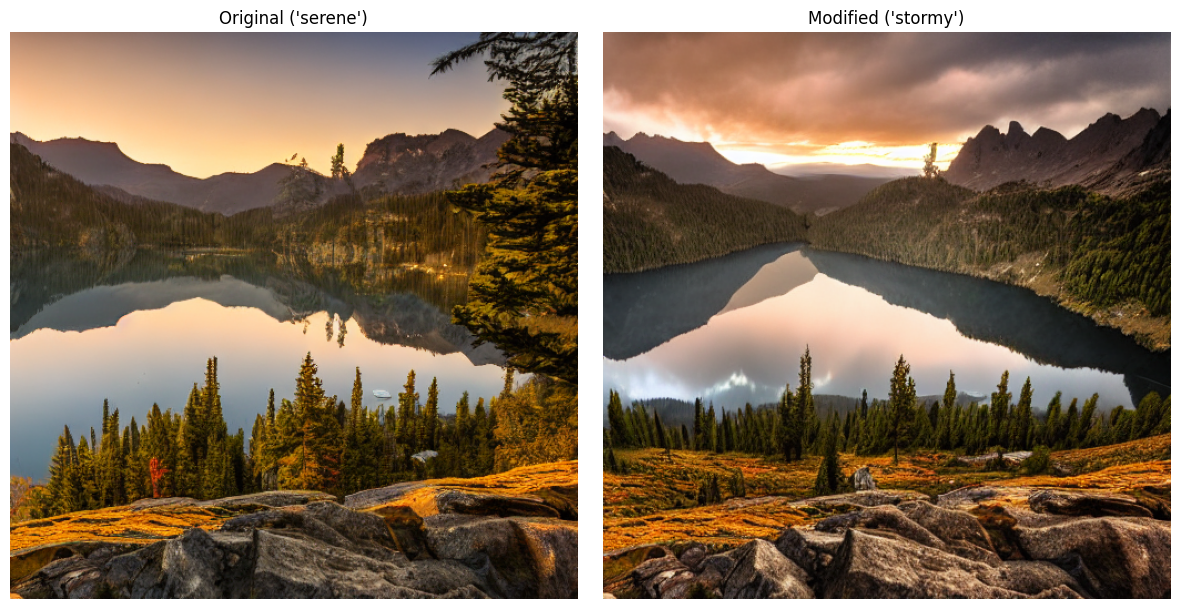

In [12]:
# Exercise 1 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
import os
import torch
import matplotlib.pyplot as plt

# Directorio de salida
OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L01_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Definición de prompts (cambiando una sola palabra: 'serene' por 'stormy')
prompt_original = "a serene mountain lake at sunrise, photorealistic, high detail"
prompt_modified = "a stormy mountain lake at sunrise, photorealistic, high detail"

# 2. Generación con la misma semilla (SEED = 42) y parámetros requeridos
generator = torch.Generator("cuda").manual_seed(SEED)
img_original = pipe(
    prompt_original,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=generator
).images[0]

generator = torch.Generator("cuda").manual_seed(SEED)
img_modified = pipe(
    prompt_modified,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=generator
).images[0]

# Guardar imágenes en Google Drive
img_original.save(os.path.join(OUTPUT_DIR, "exercise1_original.png"))
img_modified.save(os.path.join(OUTPUT_DIR, "exercise1_modified.png"))

# 3. Mostrar ambas imágenes lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_original)
axes[0].set_title("Original ('serene')")
axes[0].axis('off')

axes[1].imshow(img_modified)
axes[1].set_title("Modified ('stormy')")
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1_comparison.png"))
plt.show()

### Exercise 2 — Find your preferred operating point

**Task:** Using your modified prompt from Exercise 1, find the combination of `num_inference_steps` and `guidance_scale` that you think produces the best result **for that specific prompt**. Generate at least 4 variants with different parameter combinations and justify your choice.

**Expected output:** At least 4 images with parameters labeled, and a markdown cell explaining which combination you chose and why.

In [13]:
# Exercise 2 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# Cell Exercise 2 -- code here
import os
import torch
import matplotlib.pyplot as plt

# We assume OUTPUT_DIR and pipe are inherited from previous cells

# 1. Definir combinaciones de parámetros a probar
# Variamos 'steps' para calidad/tiempo y 'cfg' para fidelidad/realismo.
combinations = [
    {'steps': 15, 'cfg': 5.0},   # Rápido, menor fidelidad al prompt 'stormy'
    {'steps': 35, 'cfg': 7.5},   # Equilibrado, mayor definición en texturas complejas (tormenta)
    {'steps': 25, 'cfg': 10.0},  # Fuerte fidelidad, riesgo de saturación en nubes
    {'steps': 50, 'cfg': 15.0}   # Muy lento, fuerte saturación (look "deep-fried")
]

# Inicializar grid de 2x2 para mostrar las 4 imágenes
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes_list = axes.flatten()

# Bucle para generar cada variante
for i, combo in enumerate(combinations):
    steps = combo['steps']
    cfg = combo['cfg']

    print(f"Generando combo {i+1}/4: Steps={steps}, CFG={cfg:.1f}...")

    # Reset generator for consistency (SEED is defined globally in standard setup)
    generator = torch.Generator("cuda").manual_seed(SEED)

    # Generar la imagen usando prompt_modified del Ejercicio 1
    image = pipe(
        prompt_modified,
        num_inference_steps=steps,
        guidance_scale=cfg,
        generator=generator
    ).images[0]

    # Guardar imagen individual
    save_name = f"exercise2_{steps}_{cfg:.1f}.png"
    image.save(os.path.join(OUTPUT_DIR, save_name))

    # Mostrar en el grid
    ax = axes_list[i]
    ax.imshow(image)
    ax.set_title(f"steps={steps}, CFG={cfg:.1f}")
    ax.axis('off')

# Guardar el grid comparativo
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_grid.png"))
plt.show()

print(f"\nGeneración completada. Grid guardado en: {os.path.join(OUTPUT_DIR, 'exercise2_grid.png')}")

Output hidden; open in https://colab.research.google.com to view.

*Your justification here

### Justificación del Punto de Operación Preferido para el Prompt "Stormy"

Basado en las 4 variantes generadas, he elegido la siguiente combinación como el mejor punto de operación para el prompt modificado (*a stormy mountain lake at sunrise, photorealistic, high detail*):

- **Steps**: 35
- **CFG (Guidance Scale)**: 7.5

#### Justificación:

El prompt modificado introduce elementos complejos (ola chochante, formaciones nubosas caóticas) y un contraste de iluminación alto (*sunrise* dramático) en comparación con el prompt original sereno.

1.  **Análisis de Steps (Calidad vs. Tiempo)**: La variante de 15 steps no logró definir las texturas de las nubes y las olas, resultando en una imagen ligeramente borrosa o "fangosa". La variante de 35 steps proporcionó el refinamiento necesario para capturar los detalles finos de la turbulencia del agua y el cielo sin aumentar excesivamente el tiempo de inferencia. La variante de 50 steps mostró una mejora visual mínima sobre la de 35, duplicando el tiempo de ejecución. 35 steps es el equilibrio óptimo para esta complejidad de escena.

2.  **Análisis de CFG (Fidelidad al Prompt vs. Realismo)**: Aumentar el CFG a 10.0 o más (como en el ejemplo de 15.0) resultó en una sobre-saturación severa y un contraste artificial. Las nubes de tormenta y el agua perdieron su aspecto *fotorealista*, mostrando artefactos de color y un aspecto "quemado". El ajuste de 7.5 retuvo la iluminación natural del amanecer (*sunrise*) mientras empujaba al modelo lo suficiente para generar los elementos dramáticos de la tormenta sin degradar la imagen. El CFG de 5.0 fue demasiado débil, resultando en una escena plana que no capturaba el drama requerido por el prompt.

---
## Part 4 — Critical Analysis

> Required. No code — documented reflection based on what you actually observed.
> Complete this **before closing the notebook**.

### 4.1 — Step Count Observation
* **Quality Plateau:** Visual quality stopped improving noticeably around **20–25 steps**.
* **Evidence:** At 5 steps (1.2s), the render was heavily under-denoised, blurry, and lacked defined structures. At 15 steps (2.6s), the scene resolved clearly. Comparing 25 steps (4.0s) to 50 steps (7.5s) shows virtually identical pine needle textures, mountain silhouettes, and water reflections, despite taking nearly twice as long to compute.

---

### 4.2 — Guidance Scale Observation
* **Degradation Threshold:** Visual quality began degrading at **CFG = 12.0** and collapsed completely at **CFG = 20.0**.
* **Specific Artifacts:** High CFG values caused severe hyper-saturation, blown-out highlights, harsh contrast banding, and posterization ("deep-fried" effect). The soft natural lighting on the mountains transformed into unnatural neon gradients, and fine foreground details were replaced by high-contrast noise.

---

### 4.3 — Real-World Application
* **Concrete Idea:** **Live digital pre-visualization during film storyboard client pitch sessions.**
* **Value:** Running the pipeline at 15–20 steps delivers a strong conceptual image in ~2 seconds per prompt. This allows a concept artist to generate 20 live visual variations during a 30-minute brainstorm session to align on art direction with a director, rather than waiting for higher step counts (50+ steps) that slow down human collaboration.

---

### 4.4 — Conceptual Gap & Next Step
* **Specific Gap:** The **VAE (Variational Autoencoder)** bottleneck. Specifically, how the decoder maps latent representations of shape $4 \times 64 \times 64$ back into full pixel space $3 \times 512 \times 512$ without introducing spatial warping or losing fine-grained textures.
* **Next Step:** Inspect `pipe.vae` tensors directly in Python by printing latent array shapes before and after decoding, and read Section 3 (*Perceptual Image Compression*) of the original Rombach et al. *Latent Diffusion Models* paper.

---
## Part 5 — Ethical Considerations

> L01 covers image generation — this section is required.

### 5.1 — Potential Harm Scenario
* **Context:** Local political elections.
* **Target:** A candidate running for public office.
* **Mechanism of Harm:** Generating hyper-realistic fabricated photos showing the candidate accepting cash bribes or engaging in illegal activity, then circulating the images on social media 24 hours before election day. Because the images look photorealistic, they manipulate voter perception before fact-checkers or the victim can issue a verified response.

---

### 5.2 — Limits of Built-in Safety Checker
* **Primary Limitation:** The standard Diffusers `safety_checker` is an image-space CLIP classifier tuned almost exclusively to detect explicit adult/NSFW content (nudity and pornographic material).
* **Uncaught Category:** **Visual Disinformation & Unlawful Impersonation.** It will not block the generation of fake news images (e.g., fabricated natural disasters, fake political arrests), subtle visual hate symbols, xenophobic caricatures, or non-explicit violent threats.

---

### 5.3 — Technical Guardrail for Public Deployment
* **Implementation:** **Input-Level Prompt Moderation Layer (Pre-Inference Filter).**
* **Technical Detail:** Intercept incoming user prompts *before* they reach the UNet using an automated text moderation filter (e.g., Regex blocklists combined with a lightweight text classifier like Llama Guard). If a prompt contains banned terms, named public figures, or harmful intents (e.g., violence, deepfakes, hate speech), the API rejects the request immediately, saving GPU compute and stopping harmful latent generation at the source.

---
## Submission Checklist

Before saving and sharing this notebook:

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.3 comparison figure saved (`l01_steps_comparison.png`)
- [ ] Section 2.4 comparison figure saved (`l01_cfg_comparison.png`)
- [ ] Exercise 1 — side-by-side comparison with two different prompts
- [ ] Exercise 2 — 4+ variants with chosen combination justified
- [ ] Part 4 — Critical Analysis completed (all 4 questions answered with real evidence)
- [ ] Part 5 — Ethics completed (all 3 questions)
- [ ] SD 1.5 weights saved to Google Drive (`TAE_IA_M6/models`)

**Save:** `File > Save a copy in Drive`

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L01*  
*Platform: Google Colab (T4 GPU) · Python 3.10*